<a href="https://colab.research.google.com/github/nastya-kolle/mathematical-computational-modeling/blob/main/MCM_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №8. Волновое уравнение: задача Коши и смешанные задачи

**Задача.** Решить одномерное волновое уравнение `u_tt = a²*u_xx` в двух постановках:

1. Задача Коши на всей прямой (формула Даламбера) для `u_tt - u_xx = sin(x)`.
2. Первая смешанная задача (условия Дирихле на обоих концах) для колебаний струны
   длиной `l`, закреплённой на обоих концах, с заданными начальной формой и начальной
   скоростью струны.

Нужно получить аналитическое решение для каждой постановки и визуализировать форму
струны/волны в разные моменты времени.


In [ ]:
import pandas
import numpy as np
import scipy
import sympy
import math
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

ЗАДАНИЕ 1 — ЗАДАЧА КОШИ
f(x,t)=sin(x), g(x)=sin(x), h(x)=0, a=1, l=∞
Решение: u(x,t) = sin(x) [стационарное!]


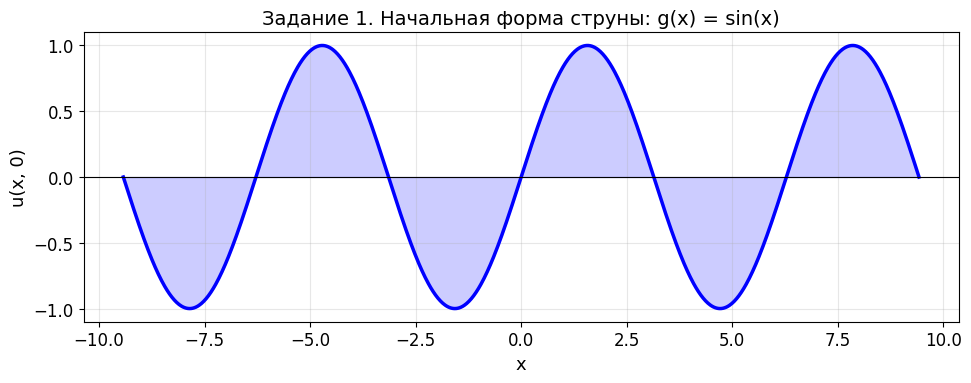

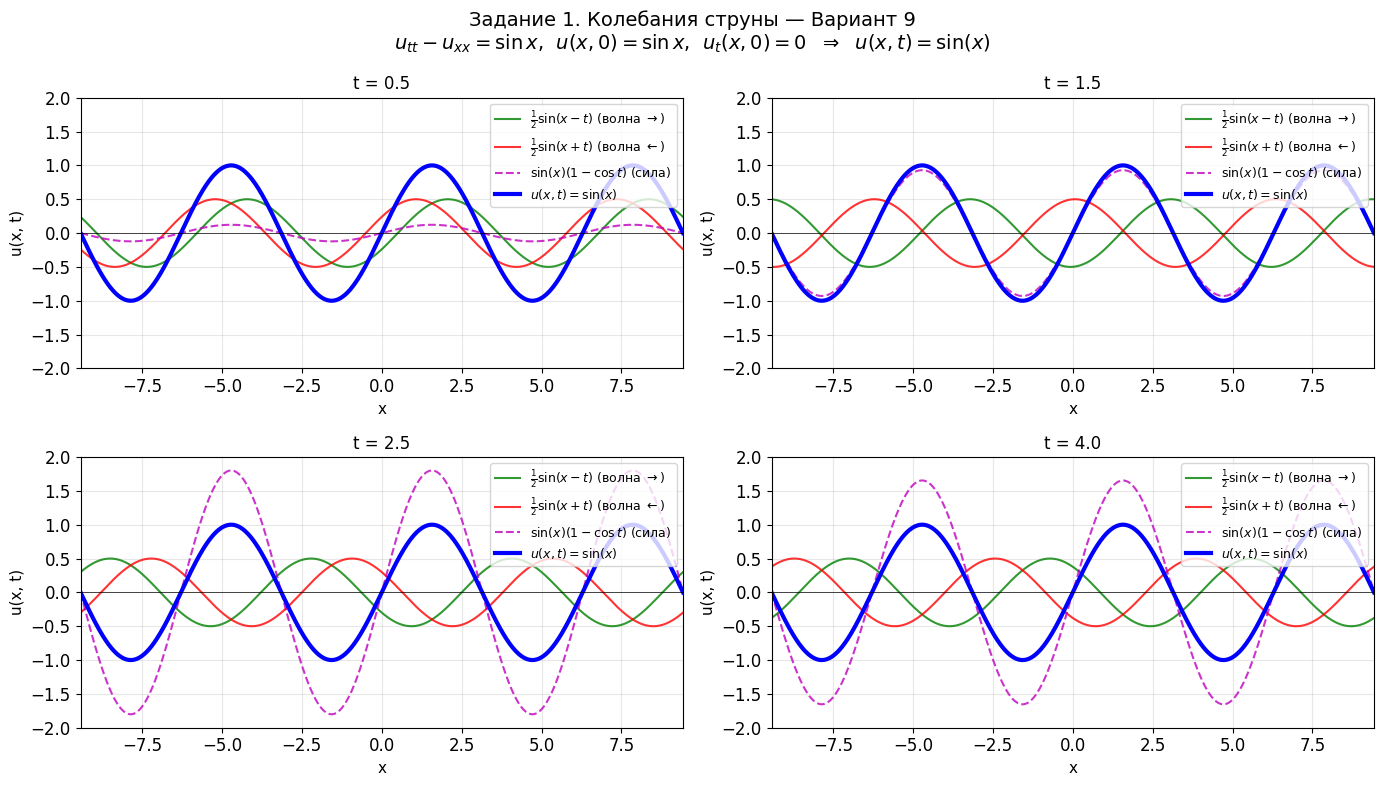


Вывод: u(x,t) = sin(x) — решение не зависит от времени.
Три слагаемых Даламбера компенсируют друг друга.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================
# ЗАДАНИЕ 1 — ЗАДАЧА КОШИ
# u_tt - u_xx = sin(x)
# u(x,0) = sin(x),  u_t(x,0) = 0,  a=1,  x∈ℝ
# Решение по формуле Даламбера: u(x,t) = sin(x) [стационарное]
# ==============================================================

print("=" * 60)
print("ЗАДАНИЕ 1 — ЗАДАЧА КОШИ")
print("f(x,t)=sin(x), g(x)=sin(x), h(x)=0, a=1, l=∞")
print("Решение: u(x,t) = sin(x) [стационарное!]")
print("=" * 60)

# ── Начальная форма струны ────────────────────────────────────
x_plot = np.linspace(-3*np.pi, 3*np.pi, 1000)

plt.figure(figsize=(10, 4))
plt.plot(x_plot, np.sin(x_plot), 'b-', linewidth=2.5)
plt.fill_between(x_plot, 0, np.sin(x_plot), alpha=0.2, color='blue')
plt.xlabel('x', fontsize=13)
plt.ylabel('u(x, 0)', fontsize=13)
plt.title('Задание 1. Начальная форма струны: g(x) = sin(x)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.8)
plt.tight_layout()
plt.savefig('task1_initial_shape.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4 графика: три слагаемых Даламбера + итог ─────────────────
# u(x,t) = sin(x-t)/2  +  sin(x+t)/2  +  sin(x)*(1-cos(t))
#         = sin(x)  для всех t

time_moments_1 = [0.5, 1.5, 2.5, 4.0]
x_range_1 = np.linspace(-3*np.pi, 3*np.pi, 1000)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, t_val in enumerate(time_moments_1):
    wave_right = np.sin(x_range_1 - t_val) / 2           # бежит вправо
    wave_left  = np.sin(x_range_1 + t_val) / 2           # бежит влево
    force_term = np.sin(x_range_1) * (1 - np.cos(t_val)) # вклад силы
    u_total    = wave_right + wave_left + force_term       # = sin(x)

    ax = axes[idx]
    ax.plot(x_range_1, wave_right, 'g-',  linewidth=1.5, alpha=0.8,
            label=r'$\frac{1}{2}\sin(x-t)$ (волна $\rightarrow$)')
    ax.plot(x_range_1, wave_left,  'r-',  linewidth=1.5, alpha=0.8,
            label=r'$\frac{1}{2}\sin(x+t)$ (волна $\leftarrow$)')
    ax.plot(x_range_1, force_term, 'm--', linewidth=1.5, alpha=0.8,
            label=r'$\sin(x)(1-\cos t)$ (сила)')
    ax.plot(x_range_1, u_total,    'b-',  linewidth=3,
            label=r'$u(x,t)=\sin(x)$')
    ax.set_title(f't = {t_val}', fontsize=12)
    ax.set_xlim([-3*np.pi, 3*np.pi])
    ax.set_ylim([-2, 2])
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlabel('x', fontsize=11)
    ax.set_ylabel('u(x, t)', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Задание 1. Колебания струны — Вариант 9\n'
    r'$u_{tt}-u_{xx}=\sin x$,  $u(x,0)=\sin x$,  $u_t(x,0)=0$'
    r'  $\Rightarrow$  $u(x,t)=\sin(x)$',
    fontsize=14)
plt.tight_layout()
plt.savefig('task1_wave_propagation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nВывод: u(x,t) = sin(x) — решение не зависит от времени.")
print("Три слагаемых Даламбера компенсируют друг друга.\n")


ТЕКСТОВОЕ ОПИСАНИЕ ЗАДАЧИ (Задание 2, пункт 2)

Рассматривается задача о свободных поперечных колебаниях
однородной струны длиной l = 9, закреплённой на обоих концах.

ТИП ЗАДАЧИ: Первая смешанная задача (условия Дирихле на обоих концах).

ФИЗИЧЕСКИЙ СМЫСЛ:
  - Оба конца струны жёстко закреплены: u(0,t) = u(9,t) = 0
  - В начальный момент струна имеет форму: φ(x) = 18·sin(14πx)
  - Начальная скорость точек струны: ψ(x) = sin(14πx)
  - Скорость распространения волны: a = 4  (a² = 16)

МАТЕМАТИЧЕСКАЯ МОДЕЛЬ:
  ∂²u/∂t² = 16·∂²u/∂x²,   0 < x < 9, t > 0
  u(x,0)  = 18·sin(14πx)   — начальное смещение
  uₜ(x,0) = sin(14πx)      — начальная скорость
  u(0,t)  = u(9,t) = 0     — закреплённые концы

МЕТОД РЕШЕНИЯ: Метод Фурье (разделение переменных).

РЕШЕНИЕ:
  u(x,t) = sin(14πx)·[18·cos(56πt) + (1/56π)·sin(56πt)]

  Ненулевой коэффициент только при n = 126:
    A₁₂₆ = 18,   B₁₂₆ = 1/(56π) ≈ 0.00568

  Физический смысл решения: стоячая волна с частотой ω = 56π,
  форма sin(14πx) не меняется —

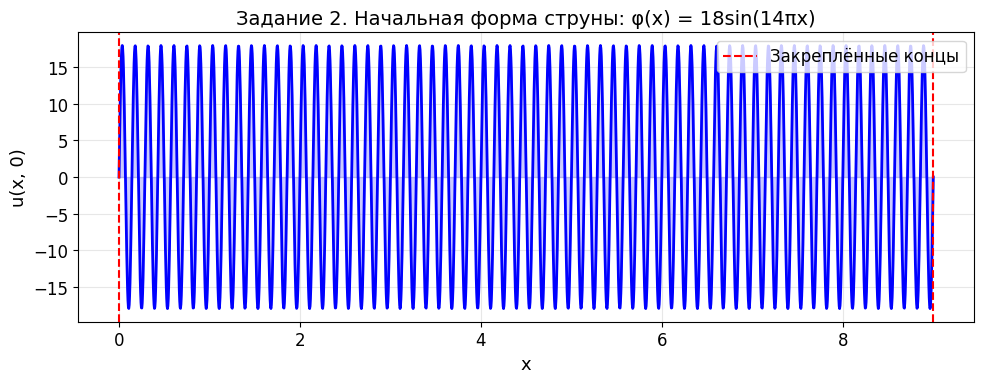

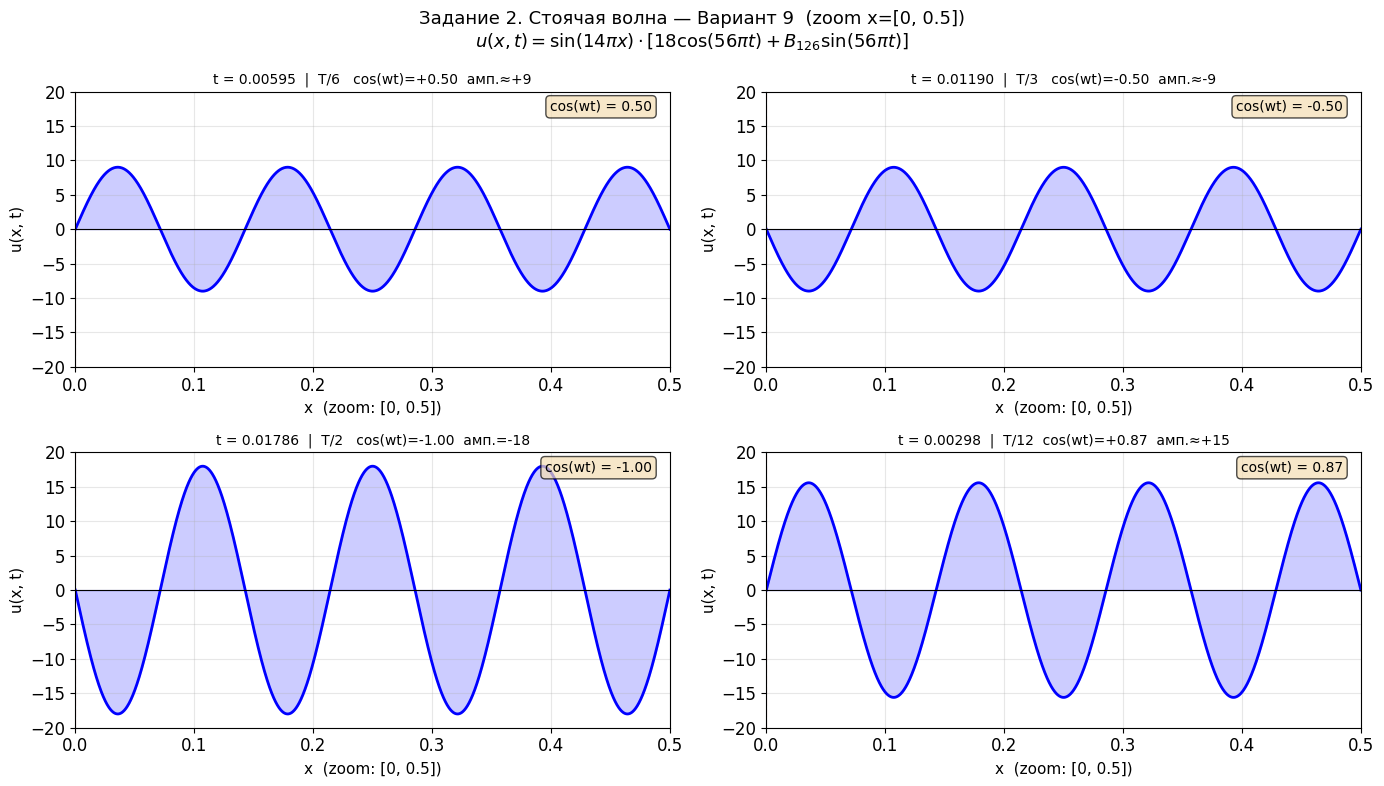

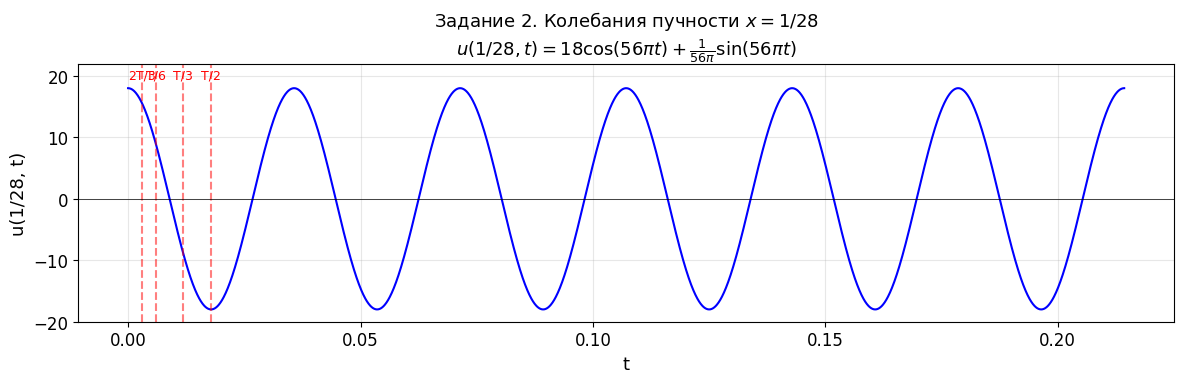


Вывод: решение — стоячая волна
u(x,t) = sin(14πx)·[18·cos(56πt) + (1/56π)·sin(56πt)]
Период T = 1/28 ≈ 0.035714
Амплитуда ≈ 18, оба конца закреплены (условия Дирихле).


In [ ]:
# ==============================================================
# ЗАДАНИЕ 2 — СМЕШАННАЯ ЗАДАЧА (1-Я: ДИРИХЛЕ–ДИРИХЛЕ)
# u_tt = 16*u_xx,  0 < x < 9,  t > 0
# u(x,0) = 18*sin(14πx),  u_t(x,0) = sin(14πx)
# u(0,t) = u(9,t) = 0
# Решение: u(x,t) = sin(14πx)*[18*cos(56πt) + (1/56π)*sin(56πt)]
# ==============================================================
print("\n" + "=" * 60)
print("ТЕКСТОВОЕ ОПИСАНИЕ ЗАДАЧИ (Задание 2, пункт 2)")
print("=" * 60)
print("""
Рассматривается задача о свободных поперечных колебаниях
однородной струны длиной l = 9, закреплённой на обоих концах.

ТИП ЗАДАЧИ: Первая смешанная задача (условия Дирихле на обоих концах).

ФИЗИЧЕСКИЙ СМЫСЛ:
  - Оба конца струны жёстко закреплены: u(0,t) = u(9,t) = 0
  - В начальный момент струна имеет форму: φ(x) = 18·sin(14πx)
  - Начальная скорость точек струны: ψ(x) = sin(14πx)
  - Скорость распространения волны: a = 4  (a² = 16)

МАТЕМАТИЧЕСКАЯ МОДЕЛЬ:
  ∂²u/∂t² = 16·∂²u/∂x²,   0 < x < 9, t > 0
  u(x,0)  = 18·sin(14πx)   — начальное смещение
  uₜ(x,0) = sin(14πx)      — начальная скорость
  u(0,t)  = u(9,t) = 0     — закреплённые концы

МЕТОД РЕШЕНИЯ: Метод Фурье (разделение переменных).

РЕШЕНИЕ:
  u(x,t) = sin(14πx)·[18·cos(56πt) + (1/56π)·sin(56πt)]

  Ненулевой коэффициент только при n = 126:
    A₁₂₆ = 18,   B₁₂₆ = 1/(56π) ≈ 0.00568

  Физический смысл решения: стоячая волна с частотой ω = 56π,
  форма sin(14πx) не меняется — меняется только амплитуда.
  Период колебаний T = 1/28 ≈ 0.0357.
""")
print("=" * 60)
print("ЗАДАНИЕ 2 — СМЕШАННАЯ ЗАДАЧА (1-я: Дирихле–Дирихле)")
print("u_tt = 16*u_xx,  0 < x < 9")
print("u(x,0)=18*sin(14πx),  u_t(x,0)=sin(14πx)")
print("u(0,t) = u(9,t) = 0")
print("=" * 60)

a2      = 4.0          # скорость волны (a²=16)
L       = 9.0          # длина струны
A_star  = 18.0         # A_126 = 18
B_star  = 1.0 / (56 * np.pi)   # B_126 = 1/(56π)
omega   = 56 * np.pi   # ω = n·π·a/L = 126·π·4/9 = 56π
T_period = 2*np.pi / omega      # T = 1/28

print(f"\nНенулевые коэффициенты Фурье:")
print(f"  n* = 126  (из условия n·π/9 = 14π)")
print(f"  A_126 = {A_star}")
print(f"  B_126 = 1/(56π) ≈ {B_star:.8f}")
print(f"  ω = 56π ≈ {omega:.4f}")
print(f"  T = 1/28 ≈ {T_period:.6f}")
print(f"  B_126 << A_126  →  u(x,t) ≈ 18·sin(14πx)·cos(56πt)")
def u_exact(x, t):
    """u(x,t) = sin(14πx)·[18·cos(56πt) + (1/56π)·sin(56πt)]"""
    return np.sin(14*np.pi*x) * \
           (A_star*np.cos(omega*t) + B_star*np.sin(omega*t))

# ── Начальная форма струны ────────────────────────────────────
x_plot2 = np.linspace(0, L, 2000)

plt.figure(figsize=(10, 4))
plt.plot(x_plot2, 18*np.sin(14*np.pi*x_plot2), 'b-', linewidth=2)
plt.fill_between(x_plot2, 0, 18*np.sin(14*np.pi*x_plot2),
                 alpha=0.2, color='blue')
plt.axvline(x=0, color='r', linestyle='--', linewidth=1.5,
            label='Закреплённые концы')
plt.axvline(x=L, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('x', fontsize=13)
plt.ylabel('u(x, 0)', fontsize=13)
plt.title('Задание 2. Начальная форма струны: φ(x) = 18sin(14πx)',
          fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task2_initial_shape.png', dpi=150, bbox_inches='tight')
plt.show()

# ОПТИМАЛЬНЫЙ набор:
time_moments_2 = [
    T_period / 6,    # cos = +0.5  → амп. ≈ +9
    T_period / 3,    # cos = -0.5  → амп. ≈ -9
    T_period / 2,    # cos = -1    → амп. = -18
    T_period / 12,   # cos = cos(π/6) = +√3/2 ≈ +0.866 → амп. ≈ +15.6
]
labels_2 = [
    'T/6   cos(wt)=+0.50  амп.≈+9',
    'T/3   cos(wt)=-0.50  амп.≈-9',
    'T/2   cos(wt)=-1.00  амп.=-18',
    'T/12  cos(wt)=+0.87  амп.≈+15',
]

x_zoom = np.linspace(0, 0.5, 2000)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (t_val, lbl) in enumerate(zip(time_moments_2, labels_2)):
    u_zoom = u_exact(x_zoom, t_val)

    ax = axes[idx]
    ax.plot(x_zoom, u_zoom, 'b-', linewidth=2)
    ax.fill_between(x_zoom, 0, u_zoom, alpha=0.2, color='blue')
    ax.set_title(f't = {t_val:.5f}  |  {lbl}', fontsize=10)
    ax.set_xlim([0, 0.5])
    ax.set_ylim([-20, 20])
    ax.axhline(y=0, color='k', linewidth=0.8)
    ax.axvline(x=0, color='r', linestyle='--', alpha=0.5)
    ax.set_xlabel('x  (zoom: [0, 0.5])', fontsize=11)
    ax.set_ylabel('u(x, t)', fontsize=11)
    ax.text(0.97, 0.93,
            f'cos(wt) = {np.cos(omega*t_val):.2f}',
            transform=ax.transAxes, ha='right', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    ax.grid(True, alpha=0.3)

plt.suptitle(
    'Задание 2. Стоячая волна — Вариант 9  (zoom x=[0, 0.5])\n'
    r'$u(x,t) = \sin(14\pi x) \cdot [18\cos(56\pi t)'
    r' + B_{126}\sin(56\pi t)]$',
    fontsize=13)
plt.tight_layout()
plt.savefig('task2_wave_propagation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Колебания точки x=1/28 (пучность стоячей волны) ──────────
# sin(14π · 1/28) = sin(π/2) = 1  →  максимальная амплитуда
t_range = np.linspace(0, 6*T_period, 3000)
u_obs   = A_star*np.cos(omega*t_range) + B_star*np.sin(omega*t_range)

plt.figure(figsize=(12, 4))
plt.plot(t_range, u_obs, 'b-', linewidth=1.5)
for t_m, lbl in zip(time_moments_2, ['T/6', 'T/3', 'T/2', '2T/3']):
    plt.axvline(x=t_m, color='r', linestyle='--', alpha=0.5)
    plt.text(t_m, 19.5, lbl, ha='center', fontsize=9, color='red')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.xlabel('t', fontsize=13)
plt.ylabel('u(1/28, t)', fontsize=13)
plt.title(
    r'Задание 2. Колебания пучности $x=1/28$'
    '\n'
    r'$u(1/28,t) = 18\cos(56\pi t) + \frac{1}{56\pi}\sin(56\pi t)$',
    fontsize=13)
plt.ylim([-20, 22])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task2_point_oscillation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nВывод: решение — стоячая волна")
print(f"u(x,t) = sin(14πx)·[18·cos(56πt) + (1/56π)·sin(56πt)]")
print(f"Период T = 1/28 ≈ {T_period:.6f}")
print(f"Амплитуда ≈ 18, оба конца закреплены (условия Дирихле).")